In [16]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.formula.api import ols
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

In [2]:
data = pd.read_csv('marketing_sales_data.csv')
data.isnull()

,TV,Radio,Social Media,Influencer,Sales
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
567,False,False,False,False,False
568,False,False,False,False,False
569,False,False,False,False,False
570,False,False,False,False,False


In [3]:
data = data.dropna(axis= 0)
data.head()

,TV,Radio,Social Media,Influencer,Sales
0,Low,1.218354,1.270444,Micro,90.054222
1,Medium,14.949791,0.274451,Macro,222.741668
2,Low,10.377258,0.061984,Mega,102.774790
3,High,26.469274,7.070945,Micro,328.239378
4,High,36.876302,7.618605,Mega,351.807328


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 569 entries, 0 to 571
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            569 non-null    object 
 1   Radio         569 non-null    float64
 2   Social Media  569 non-null    float64
 3   Influencer    569 non-null    object 
 4   Sales         569 non-null    float64
dtypes: float64(3), object(2)
memory usage: 26.7+ KB


In [5]:
data.describe()

,Radio,Social Media,Sales
count,569.000000,569.000000,569.000000
mean,18.587974,3.240304,193.457340
std,9.616712,2.198120,90.328538
min,0.194576,0.013230,31.199409
25%,10.867073,1.437485,118.742719
50%,18.744512,2.920709,198.521410
75%,25.697364,4.790840,267.803610
max,48.871161,11.260430,358.420739


In [6]:
data.describe

<bound method NDFrame.describe of          TV      Radio  Social Media Influencer       Sales
0       Low   1.218354      1.270444      Micro   90.054222
1    Medium  14.949791      0.274451      Macro  222.741668
2       Low  10.377258      0.061984       Mega  102.774790
3      High  26.469274      7.070945      Micro  328.239378
4      High  36.876302      7.618605       Mega  351.807328
..      ...        ...           ...        ...         ...
567    High  28.210738      4.373466      Micro  302.887998
568  Medium  23.578661      2.856657       Mega  232.555023
569     Low   9.169824      0.067279       Nano   73.888838
570     Low  11.563403      1.727947       Nano  121.949570
571  Medium  18.814801      3.440682       Mega  182.511614

[569 rows x 5 columns]>

In [7]:
data.shape

(569, 5)

In [8]:
data['TV'].value_counts()

TV
Medium    197
Low       196
High      176
Name: count, dtype: int64

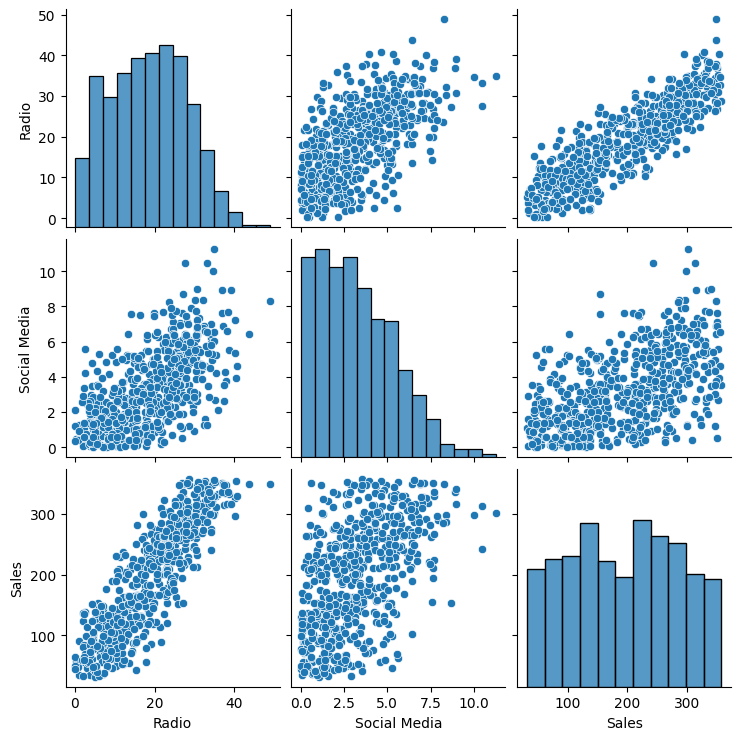

In [9]:
sns.pairplot(data=data)

In [10]:
sales_inf = data.groupby('Influencer').agg({'Sales':'mean'}).reset_index()

In [11]:
sales_tv  = data.groupby('TV').agg({'Sales':'mean'}).reset_index()

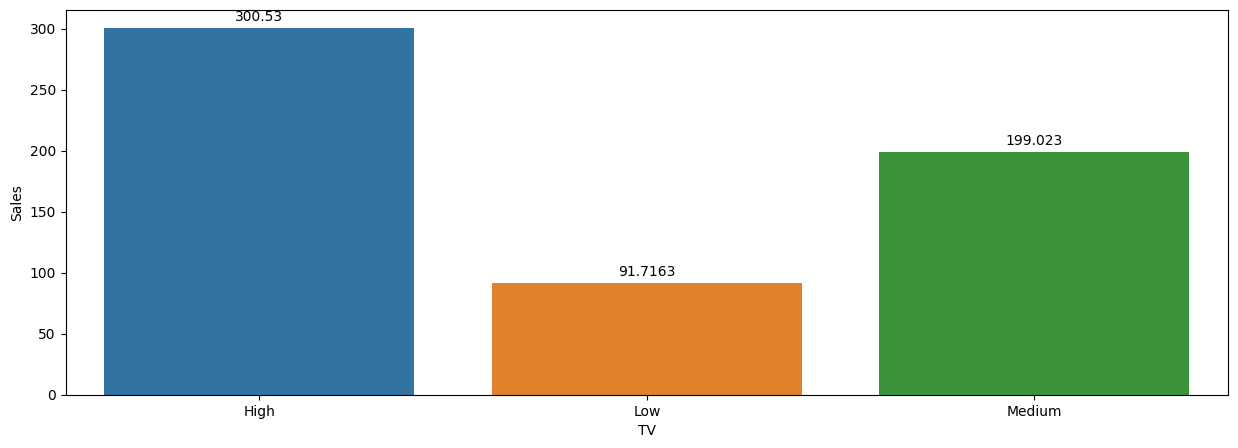

In [12]:
plt.figure(figsize=(15,5))
ax = sns.barplot(data=sales_tv, x='TV', y = 'Sales', hue  = 'TV')
for container in ax.containers:
    ax.bar_label(container,padding=3)
plt.show()

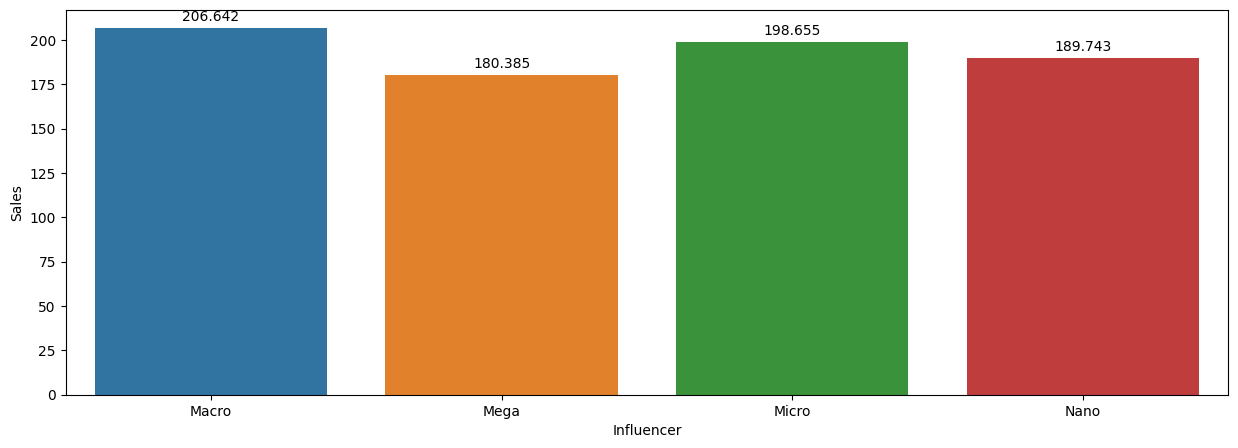

In [13]:
plt.figure(figsize=(15,5))
ax  = sns.barplot(data=sales_inf, x='Influencer', y = 'Sales', hue =  'Influencer')
for container in ax.containers:
    ax.bar_label(container, padding = 3)
plt.show()


In [40]:
data

,tv,radio,social_media,influencer,sales
0,Low,1.218354,1.270444,Micro,90.054222
1,Medium,14.949791,0.274451,Macro,222.741668
2,Low,10.377258,0.061984,Mega,102.774790
3,High,26.469274,7.070945,Micro,328.239378
4,High,36.876302,7.618605,Mega,351.807328
...,...,...,...,...,...
567,High,28.210738,4.373466,Micro,302.887998
568,Medium,23.578661,2.856657,Mega,232.555023
569,Low,9.169824,0.067279,Nano,73.888838
570,Low,11.563403,1.727947,Nano,121.949570


In [71]:
data.columns = ['tv','radio','social_media','influencer','sales']
data

,tv,radio,social_media,influencer,sales
0,Low,1.218354,1.270444,Micro,90.054222
1,Medium,14.949791,0.274451,Macro,222.741668
2,Low,10.377258,0.061984,Mega,102.774790
3,High,26.469274,7.070945,Micro,328.239378
4,High,36.876302,7.618605,Mega,351.807328
...,...,...,...,...,...
567,High,28.210738,4.373466,Micro,302.887998
568,Medium,23.578661,2.856657,Mega,232.555023
569,Low,9.169824,0.067279,Nano,73.888838
570,Low,11.563403,1.727947,Nano,121.949570


In [72]:
ols_formula = "sales ~ radio + C(tv)"

In [73]:
OLS = ols(formula = ols_formula, data = data)
model = OLS.fit()

In [74]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.904
Method:                 Least Squares   F-statistic:                     1782.
Date:                Sat, 23 May 2026   Prob (F-statistic):          1.61e-287
Time:                        14:36:30   Log-Likelihood:                -2701.4
No. Observations:                 569   AIC:                             5411.
Df Residuals:                     565   BIC:                             5428.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         217.6367      6.577     33.089      0.000     204.718     230.556
C(tv)[T.Low]     -152.0897      5.160    -29.474      0.000    -162.225    -141.954
C(tv)[T.Medium]   -73.4835      3.587    -20.484      0.000     -80.530     -66.437
radio               2.8864      0.217     13.306      0.000       2.460       3.312
==============================================================================
Omnibus:                       35.219   Durbin-Watson:                   1.949
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               13.863
Skew:                           0.087   Prob(JB):                     0.000976
Kurtosis:                       2.255   Cond. No.                         155.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<Axes: xlabel='radio', ylabel='sales'>

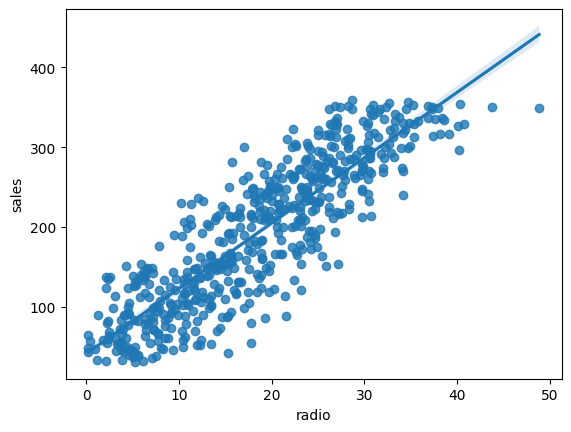

In [ ]:
sns.regplot(data = data, x = 'radio', y = 'sales')

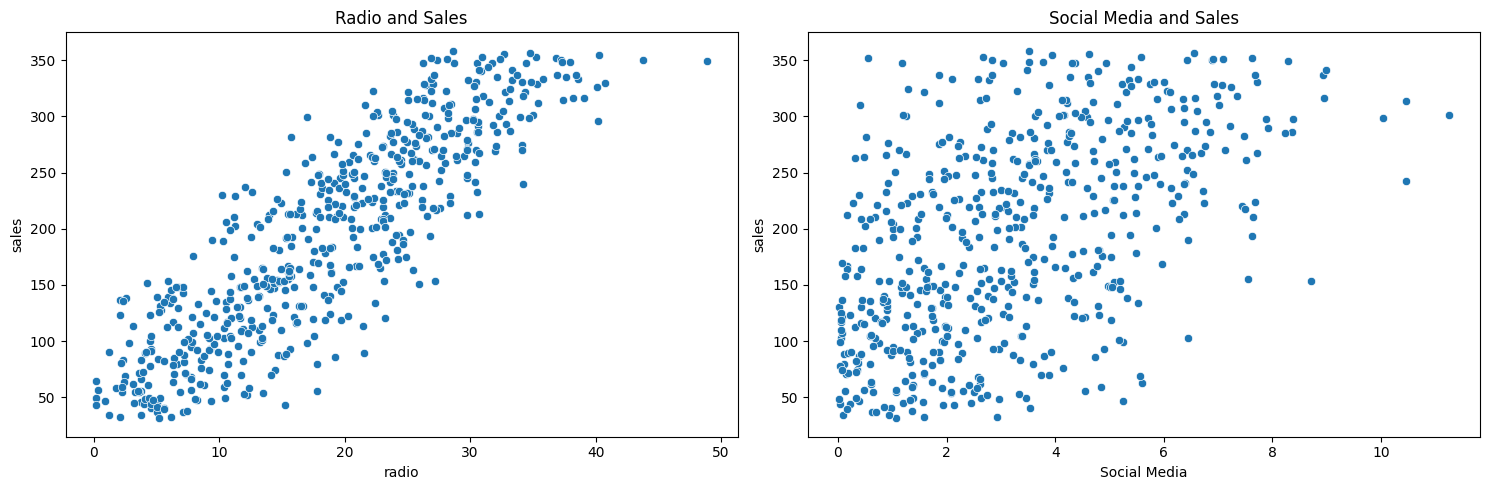

In [85]:
fig, axes = plt.subplots(1,2, figsize = (15,5))
sns.scatterplot(x = data['radio'], y = data['sales'], ax = axes[0])
axes[0].set_title("Radio and Sales")
sns.scatterplot(x = data['social_media'], y = data['sales'], ax=axes[1])
axes[1].set_title('Social Media and Sales')
axes[1].set_xlabel("Social Media")
plt.tight_layout()

In [86]:
residuals = model.resid

In [87]:
residuals

0      20.990621
1      35.437962
2       7.275269
3      34.202761
4      27.732253
         ...    
567     3.824883
568    20.345267
569   -18.125589
570    23.026402
571   -15.947912
Length: 569, dtype: float64

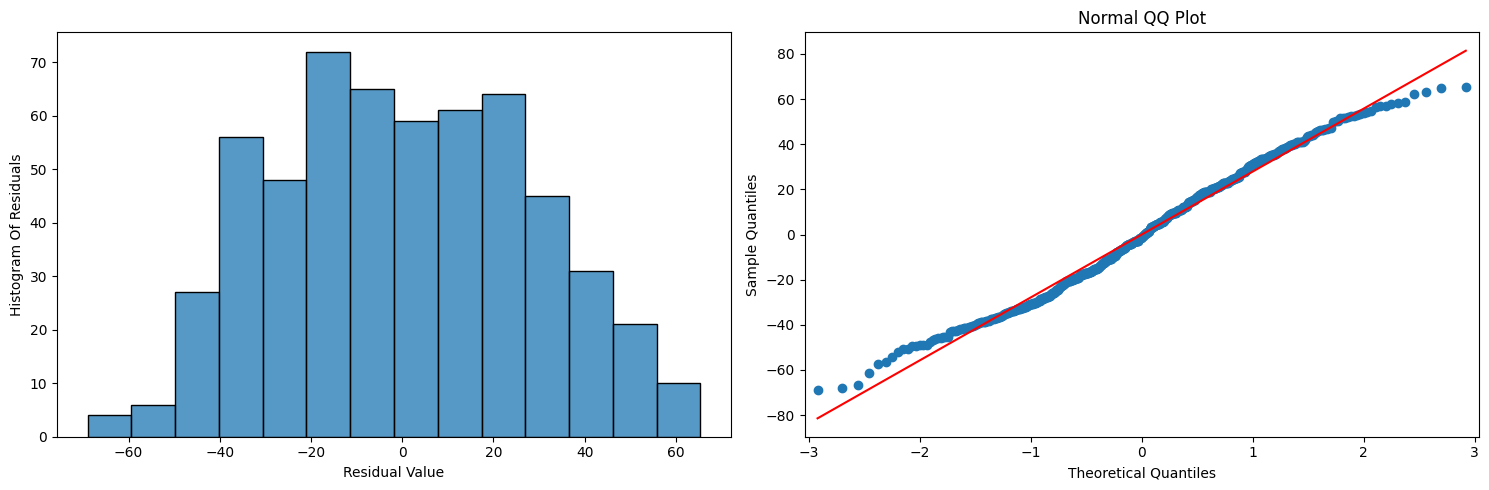

In [88]:
fig, axes = plt.subplots(1,2, figsize = (15,5))
sns.histplot(residuals, ax=axes[0])
axes[0].set_xlabel("Residual Value")
axes[0].set_ylabel("Histogram Of Residuals")
sm.qqplot(residuals, line = 's', ax = axes[1])
axes[1].set_title("Normal QQ Plot")
plt.tight_layout()
plt.show()

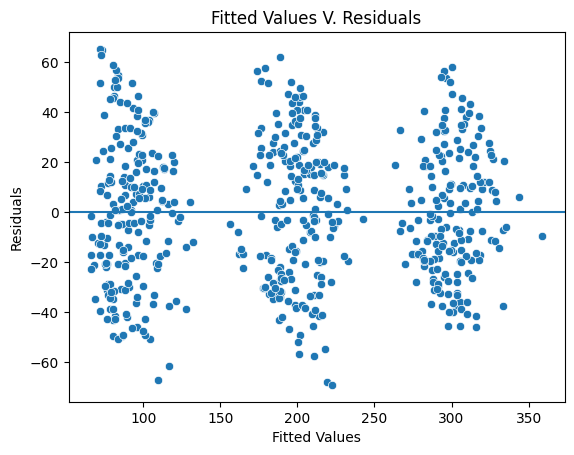

In [89]:
fig = sns.scatterplot(x = model.fittedvalues, y = model.resid)
fig.set_xlabel("Fitted Values")
fig.set_ylabel("Residuals")
fig.set_title("Fitted Values V. Residuals")
fig.axhline(0)
plt.show()

In [90]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [91]:
X = data[['radio', 'social_media']]

In [92]:
vif = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
df_vif = pd.DataFrame(vif, index=X.columns, columns=['VIF'])

In [93]:
df_vif

,VIF
radio,4.93238
social_media,4.93238
